# Análisis del dataset Titanic

# Analisis de CSV con python: TITANIC

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## T1: Carga e inspección inicial

In [52]:
# 1. Cargar el dataset directamente
df = sns.load_dataset("titanic")

In [53]:
print("Primeras filas del dataset (.head()):")
df.head()

Primeras filas del dataset (.head()):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [54]:
print("Información general y tipos de datos (.info()):")
df.info()

Información general y tipos de datos (.info()):
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [55]:
print("Estadísticas descriptivas de columnas numéricas (.describe()):")
df.describe()

Estadísticas descriptivas de columnas numéricas (.describe()):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [56]:
print(f"Forma del dataset (Filas, Columnas): {df.shape}")

Forma del dataset (Filas, Columnas): (891, 15)


## T2: Limpieza de datos (nulos y duplicados)

### 2.1. Detección y eliminación de duplicados

In [57]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

# Eliminamos las filas repetidas para no sesgar las estadísticas
df = df.drop_duplicates().reset_index(drop=True)
print(f"Filas tras eliminar duplicados: {df.shape[0]}")

Filas duplicadas encontradas: 107
Filas tras eliminar duplicados: 784


**Decisión sobre los duplicados:** se han encontrado 107 filas idénticas y se eliminan para que no cuenten dos veces en las estadísticas.

Matiz: la versión de `seaborn` no incluye `PassengerId`, así que algunas de esas filas podrían ser pasajeros distintos con los mismos valores. Se eliminan igualmente siguiendo el criterio de la actividad, y por eso la tasa de supervivencia general que sale aquí (41.2 %) es algo mayor que la del dataset completo de 891 filas (≈38 %).

### 2.2. Detección de valores nulos

In [58]:
print("Valores nulos por columna antes de limpiar:")
print(df.isna().sum()[df.isna().sum() > 0])

Valores nulos por columna antes de limpiar:
age            106
embarked         2
deck           582
embark_town      2
dtype: int64


### 2.3. Tratamiento de valores nulos

In [59]:
# Faltan más del 70% de datos; se elimina para no inventar información
if "deck" in df.columns:
    df = df.drop(columns=["deck"])
    print("-> Columna 'deck' eliminada por exceso de valores nulos (>70%).")

-> Columna 'deck' eliminada por exceso de valores nulos (>70%).


In [60]:
# Es una variable clave. Rellenamos huecos con la mediana
# para que los valores extremos no alteren la distribución
mediana_edad = df["age"].median()
df["age"] = df["age"].fillna(mediana_edad)

print(f"-> Nulos en 'age' rellenados con la mediana: {mediana_edad:.1f} años.")

-> Nulos en 'age' rellenados con la mediana: 28.2 años.


In [61]:
# Faltan muy pocos valores. Se rellenan con la moda
# (el valor más común)
moda_town = df["embark_town"].mode()[0]
df["embark_town"] = df["embark_town"].fillna(moda_town)

moda_embarked = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(moda_embarked)

print(
    f"-> Nulos en puerto de embarque rellenados con la moda: "
    f"'{moda_town}' ('{moda_embarked}')."
)

-> Nulos en puerto de embarque rellenados con la moda: 'Southampton' ('S').


**Justificación del tratamiento de nulos:**

| Columna | Nulos | Decisión | Motivo |
|---|---|---|---|
| `deck` | ~74 % | Eliminar la columna | Faltan demasiados datos; rellenarla sería inventar información |
| `age` | 106 | Rellenar con la mediana | Variable clave para el análisis; la mediana resiste mejor los valores extremos que la media |
| `embarked` / `embark_town` | 2 | Rellenar con la moda | Categóricas con muy pocos nulos; se usa el valor más frecuente |

Limitación: las 106 edades rellenadas valen todas 28.25, así que caen en el grupo 18-30 y lo inflan (380 pasajeros). Esto puede diluir la relación entre edad y supervivencia y hay que tenerlo en cuenta al interpretar los resultados.

### 2.4. Comprobación final

In [62]:
print("Comprobación de nulos tras la limpieza:")
print(df.isna().sum())

print(f"\nDimensiones finales del dataset limpio: {df.shape}")

Comprobación de nulos tras la limpieza:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Dimensiones finales del dataset limpio: (784, 14)


## T3: Transformación de datos

Se crea la columna derivada `age_group` con `np.select` (operación vectorizada, sin bucles `for`), que asigna a cada pasajero una franja de edad según varias condiciones.

In [63]:
# Crear una nueva columna agrupando a los pasajeros por edad.
# Los rangos usan < en el límite superior para no dejar huecos con edades decimales (p. ej. 30.5)
condiciones = [
    df["age"] < 13,
    (df["age"] >= 13) & (df["age"] < 18),
    (df["age"] >= 18) & (df["age"] < 31),
    (df["age"] >= 31) & (df["age"] < 51),
    df["age"] >= 51
]

grupos_edad = [
    "0-12",
    "13-17",
    "18-30",
    "31-50",
    "51+"
]

df["age_group"] = np.select(
    condiciones,
    grupos_edad,
    default="Sin grupo"
)

print("Nueva columna 'age_group':")
print(df[["age", "age_group"]].head(10))

print("\nNúmero de pasajeros por grupo de edad:")
print(df["age_group"].value_counts().sort_index())

Nueva columna 'age_group':
     age age_group
0  22.00     18-30
1  38.00     31-50
2  26.00     18-30
3  35.00     31-50
4  35.00     31-50
5  28.25     18-30
6  54.00       51+
7   2.00      0-12
8  27.00     18-30
9  14.00     13-17

Número de pasajeros por grupo de edad:
age_group
0-12      68
13-17     42
18-30    380
31-50    230
51+       64
Name: count, dtype: int64


## T4: Análisis de datos

### 4.1. Porcentaje de supervivencia general

In [64]:
supervivencia_general = df["survived"].mean() * 100

print(
    f"1. Porcentaje de pasajeros que sobrevivieron: "
    f"{supervivencia_general:.2f}%"
)

1. Porcentaje de pasajeros que sobrevivieron: 41.20%


### 4.2. Supervivencia según sexo

In [65]:
supervivencia_sexo = df.groupby("sex")["survived"].mean() * 100

print("2. Tasa de supervivencia por sexo:")
print(supervivencia_sexo)

2. Tasa de supervivencia por sexo:
sex
female    74.061433
male      21.588595
Name: survived, dtype: float64


### 4.3. Supervivencia según clase

In [66]:
supervivencia_clase = df.groupby("pclass")["survived"].mean() * 100

print("3. Tasa de supervivencia por clase:")
print(supervivencia_clase)

3. Tasa de supervivencia por clase:
pclass
1    63.084112
2    50.909091
3    25.679012
Name: survived, dtype: float64


### 4.4. Supervivencia según grupo de edad

In [67]:
supervivencia_edad = df.groupby("age_group")["survived"].mean() * 100

print("4. Tasa de supervivencia por grupo de edad:")
print(supervivencia_edad)

4. Tasa de supervivencia por grupo de edad:
age_group
0-12     57.352941
13-17    50.000000
18-30    37.105263
31-50    43.478261
51+      34.375000
Name: survived, dtype: float64


### 4.5. Grupo de edad con mayor supervivencia

In [68]:
grupo_mayor_supervivencia = supervivencia_edad.idxmax()
mayor_supervivencia = supervivencia_edad.max()

print(
    f"5. Grupo de edad con mayor proporción de supervivientes: "
    f"{grupo_mayor_supervivencia} ({mayor_supervivencia:.2f}%)"
)

5. Grupo de edad con mayor proporción de supervivientes: 0-12 (57.35%)


### 4.6. Supervivencia combinando sexo y clase

In [69]:
supervivencia_sexo_clase = (
    df.groupby(["sex", "pclass"])["survived"].mean() * 100
)

print("6. Tasa de supervivencia por sexo y clase:")
print(supervivencia_sexo_clase)

6. Tasa de supervivencia por sexo y clase:
sex     pclass
female  1         96.774194
        2         91.780822
        3         47.244094
male    1         37.190083
        2         18.478261
        3         15.827338
Name: survived, dtype: float64


### 4.7. Estadísticas adicionales

In [70]:
print("7. Estadísticas adicionales:")

print(f"Número total de pasajeros: {df.shape[0]}")
print(f"Edad media: {df['age'].mean():.2f} años")
print(f"Edad mediana: {df['age'].median():.2f} años")
print(f"Tarifa media: {df['fare'].mean():.2f}")
print(f"Tarifa máxima: {df['fare'].max():.2f}")

7. Estadísticas adicionales:
Número total de pasajeros: 784
Edad media: 29.65 años
Edad mediana: 28.25 años
Tarifa media: 34.71
Tarifa máxima: 512.33


### 4.8. Filtros con dos condiciones

In [71]:
# Mujeres de primera clase
mujeres_primera = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

print(
    f"8. Mujeres de primera clase: "
    f"{mujeres_primera.shape[0]} pasajeros"
)


# Hombres de tercera clase que no sobrevivieron
hombres_tercera_no_sobrevivieron = df[
    (df["sex"] == "male") &
    (df["pclass"] == 3) &
    (df["survived"] == 0)
]

print(
    f"Hombres de tercera clase que no sobrevivieron: "
    f"{hombres_tercera_no_sobrevivieron.shape[0]} pasajeros"
)

8. Mujeres de primera clase: 93 pasajeros
Hombres de tercera clase que no sobrevivieron: 234 pasajeros


### 4.9. Relación entre edad y supervivencia

In [72]:
corr_edad = df["age"].corr(df["survived"])

print(f"9. Correlación entre edad y supervivencia: {corr_edad:.3f}")

9. Correlación entre edad y supervivencia: -0.079


### 4.10. Gráficos de apoyo

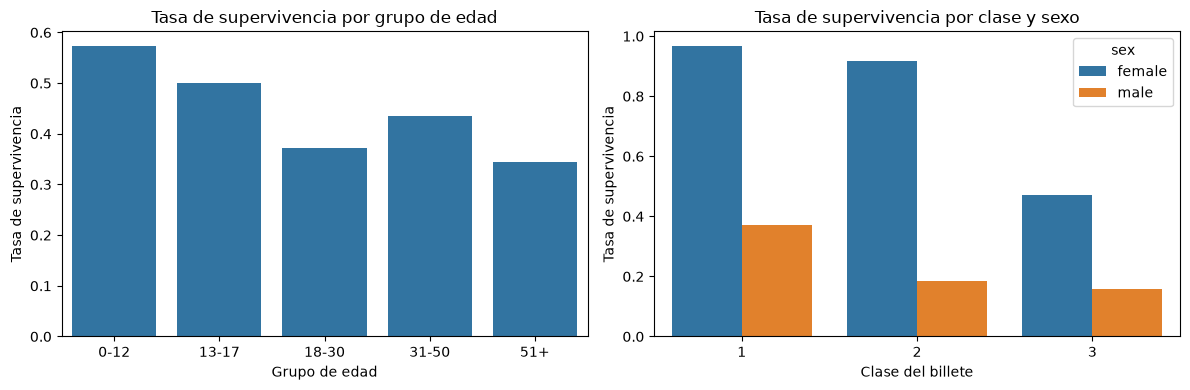

In [73]:
orden_edad = ["0-12", "13-17", "18-30", "31-50", "51+"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="age_group", y="survived", order=orden_edad,
            errorbar=None, ax=axes[0])
axes[0].set_title("Tasa de supervivencia por grupo de edad")
axes[0].set_xlabel("Grupo de edad")
axes[0].set_ylabel("Tasa de supervivencia")

sns.barplot(data=df, x="pclass", y="survived", hue="sex",
            errorbar=None, ax=axes[1])
axes[1].set_title("Tasa de supervivencia por clase y sexo")
axes[1].set_xlabel("Clase del billete")
axes[1].set_ylabel("Tasa de supervivencia")

plt.tight_layout()
plt.show()

## T5: Conclusiones

### 5.1. Conclusión sobre la supervivencia general

In [74]:
print(
    f"1. La tasa de supervivencia general fue del "
    f"{supervivencia_general:.2f}%. "
    "Esto indica que menos de la mitad de los pasajeros del "
    "dataset sobrevivieron."
)

1. La tasa de supervivencia general fue del 41.20%. Esto indica que menos de la mitad de los pasajeros del dataset sobrevivieron.


### 5.2. Conclusión sobre el sexo

In [75]:
etiquetas = {"female": "mujeres", "male": "hombres"}

sexo_mayor = etiquetas[supervivencia_sexo.idxmax()]
sexo_mayor_valor = supervivencia_sexo.max()

sexo_menor = etiquetas[supervivencia_sexo.idxmin()]
sexo_menor_valor = supervivencia_sexo.min()

print(
    f"2. La tasa de supervivencia fue diferente según el sexo. "
    f"El grupo con mayor tasa fue el de {sexo_mayor}, con un "
    f"{sexo_mayor_valor:.2f}%, mientras que el de {sexo_menor} tuvo "
    f"un {sexo_menor_valor:.2f}%."
)

2. La tasa de supervivencia fue diferente según el sexo. El grupo con mayor tasa fue el de mujeres, con un 74.06%, mientras que el de hombres tuvo un 21.59%.


### 5.3. Conclusión sobre la clase

In [76]:
clase_mayor = supervivencia_clase.idxmax()
clase_mayor_valor = supervivencia_clase.max()

clase_menor = supervivencia_clase.idxmin()
clase_menor_valor = supervivencia_clase.min()

print(
    f"3. La clase del billete también mostró diferencias en la "
    f"supervivencia. La clase {clase_mayor} presentó la mayor "
    f"tasa de supervivencia ({clase_mayor_valor:.2f}%), mientras "
    f"que la clase {clase_menor} presentó la menor "
    f"({clase_menor_valor:.2f}%)."
)

3. La clase del billete también mostró diferencias en la supervivencia. La clase 1 presentó la mayor tasa de supervivencia (63.08%), mientras que la clase 3 presentó la menor (25.68%).


### 5.4. Conclusión sobre la edad

In [77]:
print(
    f"4. Al analizar los grupos de edad, el grupo "
    f"{grupo_mayor_supervivencia} presentó la mayor proporción "
    f"de supervivientes, con un {mayor_supervivencia:.2f}%."
)

4. Al analizar los grupos de edad, el grupo 0-12 presentó la mayor proporción de supervivientes, con un 57.35%.


### 5.5. Conclusión sobre sexo y clase

In [78]:
combinacion_mayor = supervivencia_sexo_clase.idxmax()
valor_combinacion_mayor = supervivencia_sexo_clase.max()

print(
    f"5. La combinación de sexo y clase también mostró "
    f"diferencias en la supervivencia. La combinación con mayor tasa "
    f"fue la de {etiquetas[combinacion_mayor[0]]} de clase "
    f"{combinacion_mayor[1]}, con una tasa de supervivencia del "
    f"{valor_combinacion_mayor:.2f}%."
)

5. La combinación de sexo y clase también mostró diferencias en la supervivencia. La combinación con mayor tasa fue la de mujeres de clase 1, con una tasa de supervivencia del 96.77%.


### 5.6. Respuestas a las preguntas guía

**1. ¿Qué porcentaje de pasajeros sobrevivió en total?**
Sobrevivió el 41.20 % (sobre 784 pasajeros tras eliminar duplicados). Menos de la mitad.

**2. ¿Cómo varía la tasa de supervivencia según el sexo?**
Muchísimo: sobrevivió el 74.06 % de las mujeres frente al 21.59 % de los hombres, una diferencia de unos 52 puntos.

**3. ¿Y según la clase del billete?**
Baja al empeorar la clase: 63.08 % en 1ª, 50.91 % en 2ª y 25.68 % en 3ª.

**4. ¿Existe relación entre la edad y la probabilidad de supervivencia?**
Solo débil. La correlación entre edad y supervivencia es de -0.079, casi nula. Por grupos: 57.35 % (0-12), 50.00 % (13-17), 37.11 % (18-30), 43.48 % (31-50) y 34.38 % (51+). La tendencia general es descendente (los más jóvenes sobreviven más), pero no es lineal: el grupo 31-50 supera al 18-30. Además, las edades imputadas con la mediana están todas en el grupo 18-30, lo que puede distorsionar este resultado.

**5. ¿Qué franja de edad tiene mayor proporción de supervivientes?**
La de 0-12 años, con un 57.35 %. Es un grupo pequeño (68 pasajeros), así que conviene interpretarlo con cautela.

**6. (Opcional) ¿La combinación de sexo y clase cambia mucho la tasa respecto a mirar cada variable por separado?**
Sí. Mirando solo la clase, la 1ª tiene un 63 % de supervivencia, pero los hombres de 1ª solo llegan al 37.19 % mientras que las mujeres de 1ª alcanzan el 96.77 %. En 3ª ocurre al revés: la media de la clase es del 25.68 %, pero las mujeres de 3ª llegan al 47.24 % y los hombres de 3ª se quedan en el 15.83 %. El sexo pesa más que la clase, y la clase importa sobre todo entre las mujeres (91-97 % en 1ª y 2ª frente al 47 % en 3ª).

### 5.7. Conclusiones finales

1. **Menos de la mitad sobrevivió:** la tasa general es del 41.20 %.
2. **El sexo fue el factor más determinante:** las mujeres (74.06 %) sobrevivieron más de tres veces más que los hombres (21.59 %).
3. **La clase también influyó:** la supervivencia cae de 63.08 % en 1ª a 25.68 % en 3ª.
4. **Los niños de 0-12 años tuvieron la mayor supervivencia (57.35 %)**, pero fuera de ese grupo la relación entre edad y supervivencia es débil (correlación de -0.079).
5. **Sexo y clase combinados matizan todo lo anterior:** las mujeres de 1ª y 2ª clase superaron el 90 % de supervivencia, mientras que los hombres de 3ª solo llegaron al 15.83 %.